In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [3]:
import os

print(os.getcwd())

C:\Users\LENOVO\Desktop\MutualFundProject\notebooks


In [5]:
fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

In [7]:
print("Fund Master:", fund_master.shape)
print("NAV:", nav.shape)
print("Performance:", performance.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV: (46000, 3)
Performance: (40, 19)
Benchmark: (8050, 3)


In [9]:
print(nav.columns.tolist())
print(performance.columns.tolist())
print(benchmark.columns.tolist())

['amfi_code', 'date', 'nav']
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
['date', 'index_name', 'close_value']


In [11]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [13]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [15]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


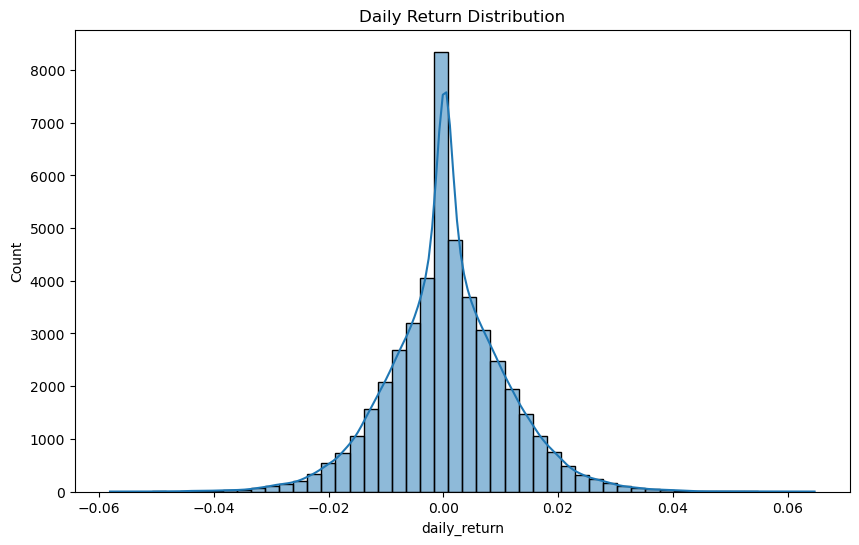

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")

plt.show()

# Daily Return Analysis

Daily returns are centered around zero, with most observations concentrated within a narrow range. This indicates relatively stable day-to-day performance with limited extreme fluctuations.

In [19]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [21]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

# CAGR Analysis

In [23]:
cagr_df = performance[
    [
        "amfi_code",
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct"
    ]
].copy()

cagr_df.head()

,amfi_code,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,119552,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,119598,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,119599,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [25]:
top_10_cagr = cagr_df.sort_values(
    "return_5yr_pct",
    ascending=False
).head(10)

top_10_cagr

,amfi_code,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
29,101207,ABSL Small Cap Fund - Regular - Growth,24.93,22.38,23.80
27,119095,Axis Small Cap Fund - Regular - Growth,21.97,20.98,22.62
17,118634,Nippon India Small Cap Fund - Regular - Growth,21.30,20.15,21.88
3,119599,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
2,119598,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
39,149324,DSP Small Cap Fund - Regular - Growth,20.20,20.08,20.61
38,149323,DSP Midcap Fund - Regular - Growth,14.12,17.16,19.00
26,119094,Axis Midcap Fund - Regular - Growth,14.88,15.18,18.94
21,120842,Kotak Emerging Equity Fund - Regular - Growth,17.12,18.23,17.75
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,15.43,16.58,17.69


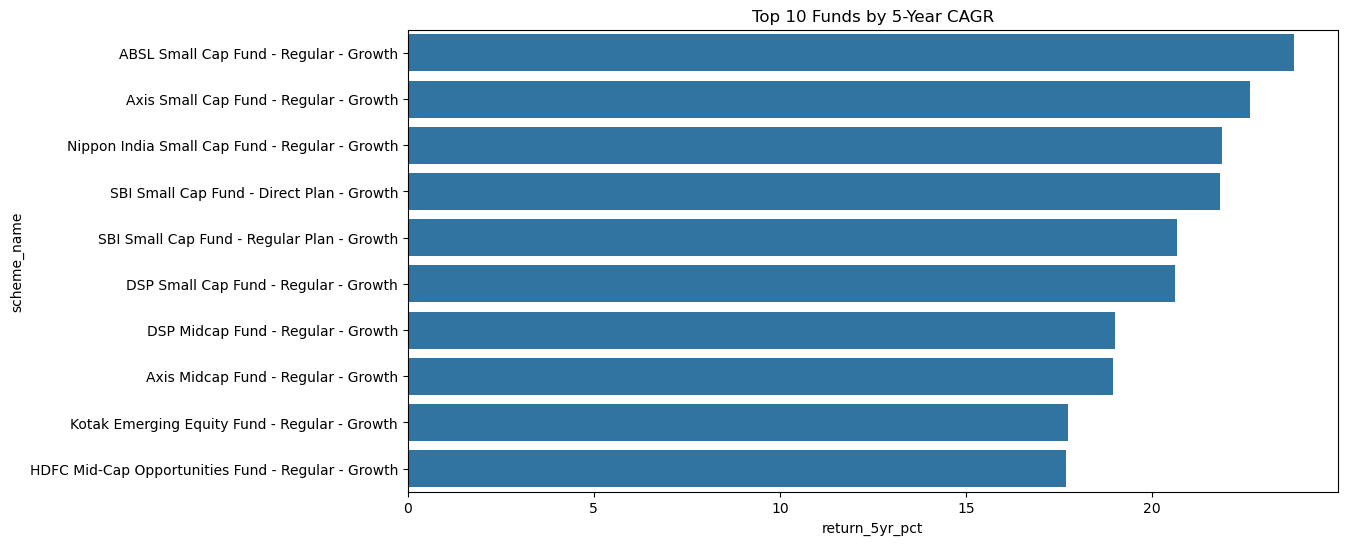

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_10_cagr,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 5-Year CAGR")

plt.show()

### CAGR Insight

Several funds have delivered strong long-term returns over the 5-year period, demonstrating the power of disciplined investing and compounding.

In [31]:
top_sharpe = performance[
    [
        "scheme_name",
        "sharpe_ratio"
    ]
].sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

top_sharpe

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


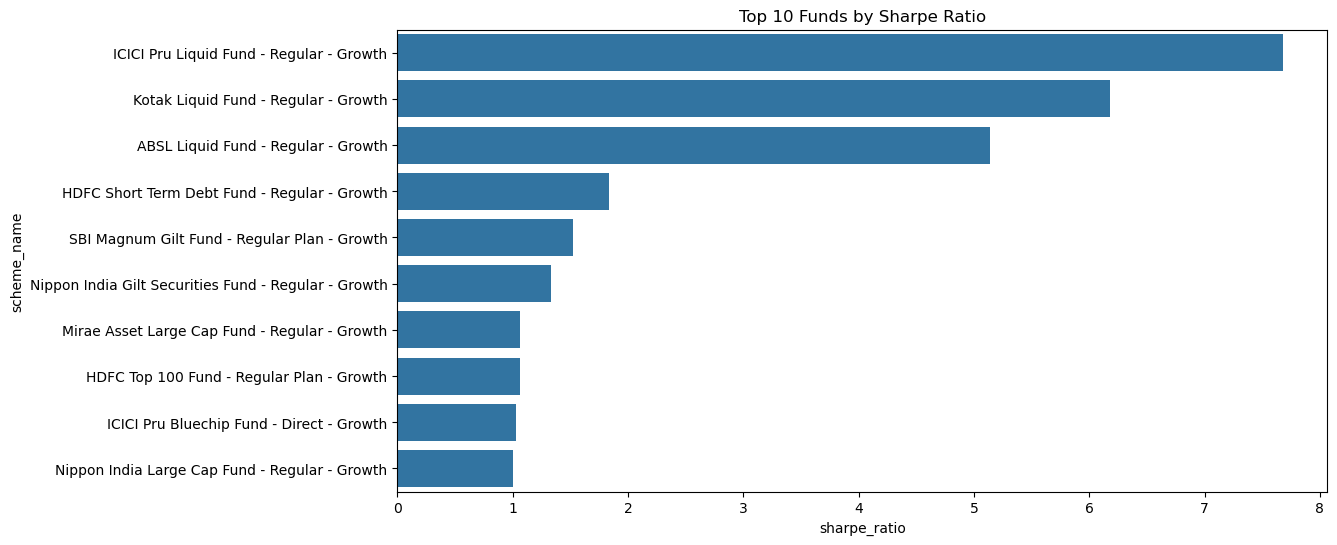

In [33]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.show()

### Sharpe Ratio Insight

Funds with higher Sharpe Ratios generated better risk-adjusted returns, offering superior reward for the risk undertaken.

In [36]:
top_sortino = performance[
    [
        "scheme_name",
        "sortino_ratio"
    ]
].sort_values(
    "sortino_ratio",
    ascending=False
).head(10)

top_sortino

,scheme_name,sortino_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,10.37
23,Kotak Liquid Fund - Regular - Growth,9.70
30,ABSL Liquid Fund - Regular - Growth,8.76
9,HDFC Short Term Debt Fund - Regular - Growth,2.79
19,Nippon India Gilt Securities Fund - Regular - ...,2.38
4,SBI Magnum Gilt Fund - Regular Plan - Growth,2.11
5,HDFC Top 100 Fund - Regular Plan - Growth,1.70
15,Nippon India Large Cap Fund - Regular - Growth,1.68
3,SBI Small Cap Fund - Direct Plan - Growth,1.67
34,Mirae Asset Large Cap Fund - Regular - Growth,1.66


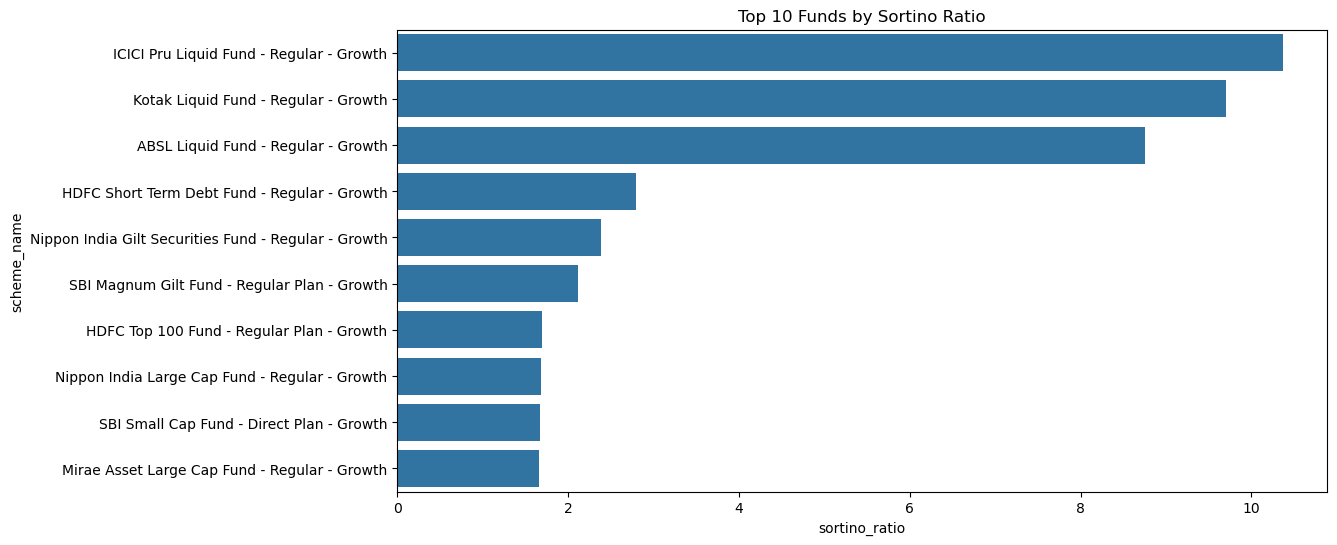

In [38]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sortino,
    x="sortino_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.show()

### Sortino Ratio Insight

Top-ranked funds demonstrated strong returns while effectively controlling downside risk during market fluctuations.

In [41]:
performance[
    [
        "scheme_name",
        "alpha",
        "beta",
        "max_drawdown_pct"
    ]
].head()

,scheme_name,alpha,beta,max_drawdown_pct
0,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89,-21.70
1,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87,-24.43
2,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89,-13.35
3,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04,-24.78
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22,-2.30


In [43]:
top_alpha = performance[
    [
        "scheme_name",
        "alpha"
    ]
].sort_values(
    "alpha",
    ascending=False
).head(10)

top_alpha

,scheme_name,alpha
9,HDFC Short Term Debt Fund - Regular - Growth,1.98
21,Kotak Emerging Equity Fund - Regular - Growth,1.91
14,ICICI Pru Liquid Fund - Regular - Growth,1.85
22,Kotak Flexicap Fund - Regular - Growth,1.85
29,ABSL Small Cap Fund - Regular - Growth,1.84
37,DSP Top 100 Equity Fund - Regular - Growth,1.82
18,Nippon India ETF Nifty 50 BeES,1.80
33,UTI Flexi Cap Fund - Regular - Growth,1.79
1,SBI Bluechip Fund - Direct Plan - Growth,1.78
35,Mirae Asset Emerging Bluechip Fund - Regular -...,1.70


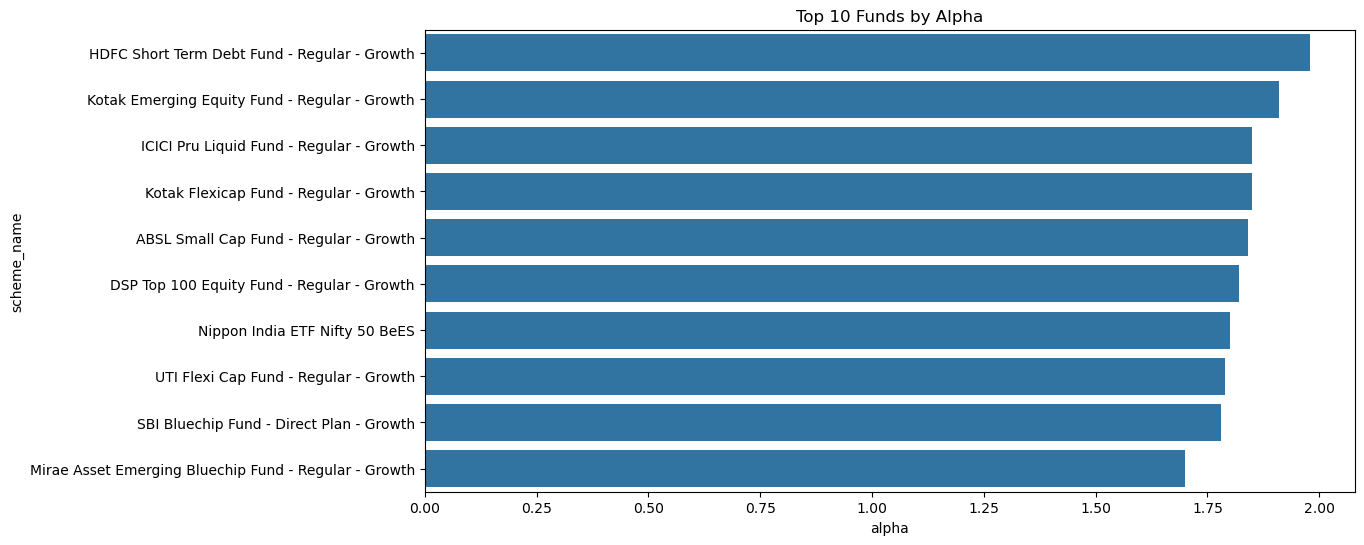

In [45]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_alpha,
    x="alpha",
    y="scheme_name"
)

plt.title("Top 10 Funds by Alpha")

plt.show()

### Alpha Insight

Funds with higher alpha consistently outperformed their benchmark after adjusting for market risk.

In [48]:
low_beta = performance[
    [
        "scheme_name",
        "beta"
    ]
].sort_values(
    "beta"
).head(10)

low_beta


,scheme_name,beta
4,SBI Magnum Gilt Fund - Regular Plan - Growth,0.22
14,ICICI Pru Liquid Fund - Regular - Growth,0.26
19,Nippon India Gilt Securities Fund - Regular - ...,0.37
30,ABSL Liquid Fund - Regular - Growth,0.43
9,HDFC Short Term Debt Fund - Regular - Growth,0.44
23,Kotak Liquid Fund - Regular - Growth,0.47
1,SBI Bluechip Fund - Direct Plan - Growth,0.87
25,Axis Bluechip Fund - Direct - Growth,0.87
15,Nippon India Large Cap Fund - Regular - Growth,0.88
0,SBI Bluechip Fund - Regular Plan - Growth,0.89


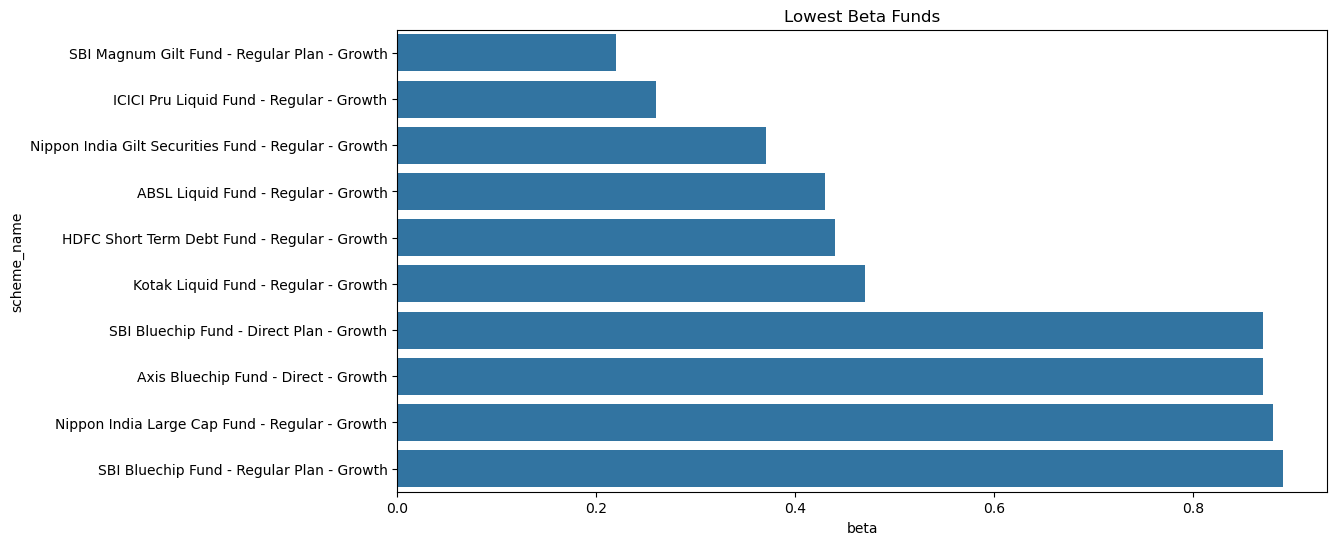

In [50]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=low_beta,
    x="beta",
    y="scheme_name"
)

plt.title("Lowest Beta Funds")

plt.show()

### Beta Insight

Lower beta funds tend to be less sensitive to market movements and may provide stability during volatile periods.

In [53]:
drawdown = performance[
    [
        "scheme_name",
        "max_drawdown_pct"
    ]
].sort_values(
    "max_drawdown_pct",
    ascending=False
).head(10)

drawdown

,scheme_name,max_drawdown_pct
19,Nippon India Gilt Securities Fund - Regular - ...,-2.23
4,SBI Magnum Gilt Fund - Regular Plan - Growth,-2.30
14,ICICI Pru Liquid Fund - Regular - Growth,-2.62
30,ABSL Liquid Fund - Regular - Growth,-3.66
23,Kotak Liquid Fund - Regular - Growth,-3.81
9,HDFC Short Term Debt Fund - Regular - Growth,-6.01
33,UTI Flexi Cap Fund - Regular - Growth,-12.14
2,SBI Small Cap Fund - Regular Plan - Growth,-13.35
32,UTI Mid Cap Fund - Regular - Growth,-13.43
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-13.67


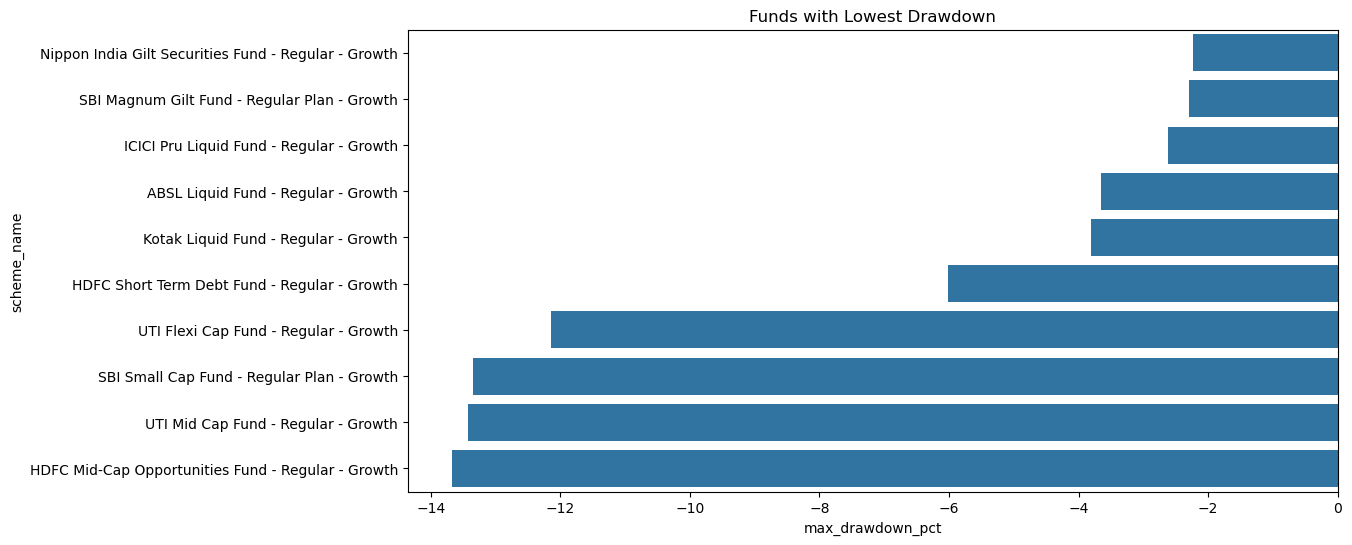

In [55]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=drawdown,
    x="max_drawdown_pct",
    y="scheme_name"
)

plt.title("Funds with Lowest Drawdown")

plt.show()

### Drawdown Insight

Funds with smaller maximum drawdowns demonstrated better downside protection during market corrections.

In [58]:
scorecard = performance.copy()

scorecard["score"] = (
    0.40 * scorecard["return_5yr_pct"]
    +
    0.30 * scorecard["sharpe_ratio"] * 10
    +
    0.20 * scorecard["alpha"] * 10
    +
    0.10 * (-scorecard["max_drawdown_pct"])
)

scorecard = scorecard.sort_values(
    "score",
    ascending=False
)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,score
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low,30.178
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low,25.265
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,0.43,5.14,8.76,0.5,-3.66,38995,0.79,5,Low,21.326
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,0.97,0.90,1.47,25.0,-23.61,41613,1.53,5,Very High,18.261
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,16.256


In [60]:
top_scorecard = scorecard[
    [
        "scheme_name",
        "score"
    ]
].head(10)

top_scorecard

,scheme_name,score
14,ICICI Pru Liquid Fund - Regular - Growth,30.178
23,Kotak Liquid Fund - Regular - Growth,25.265
30,ABSL Liquid Fund - Regular - Growth,21.326
29,ABSL Small Cap Fund - Regular - Growth,18.261
3,SBI Small Cap Fund - Direct Plan - Growth,16.256
26,Axis Midcap Fund - Regular - Growth,16.054
21,Kotak Emerging Equity Fund - Regular - Growth,15.992
17,Nippon India Small Cap Fund - Regular - Growth,15.869
35,Mirae Asset Emerging Bluechip Fund - Regular -...,15.717
38,DSP Midcap Fund - Regular - Growth,15.039


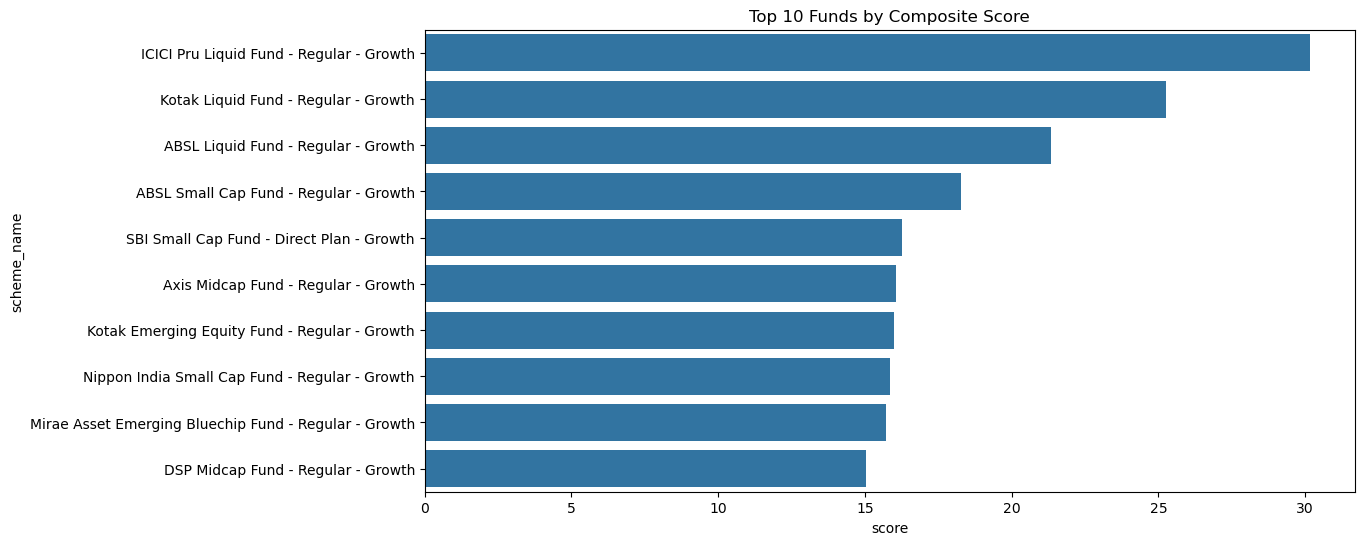

In [62]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_scorecard,
    x="score",
    y="scheme_name"
)

plt.title("Top 10 Funds by Composite Score")

plt.show()

### Composite Score Insight

The composite scoring model identifies funds that balance return generation, risk-adjusted performance, alpha generation, and downside protection.

In [65]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [67]:
performance[
    [
        "scheme_name",
        "alpha",
        "beta"
    ]
].to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


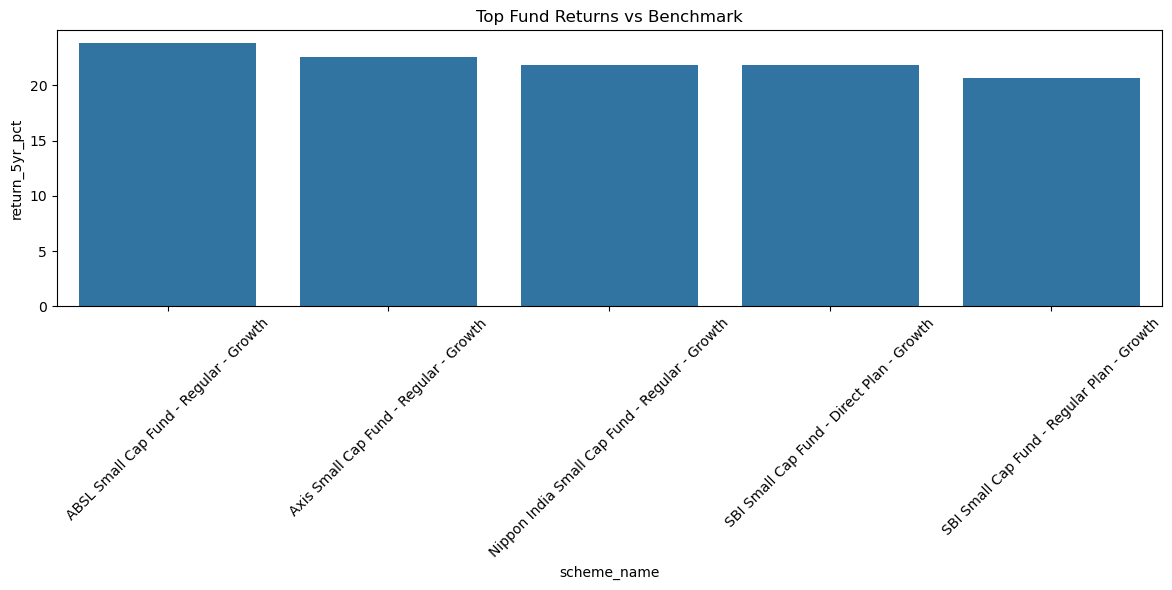

In [69]:
top_funds = performance.sort_values(
    "return_5yr_pct",
    ascending=False
).head(5)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_funds,
    x="scheme_name",
    y="return_5yr_pct"
)

plt.xticks(rotation=45)

plt.title("Top Fund Returns vs Benchmark")

plt.tight_layout()

plt.savefig("../reports/benchmark_comparison.png")

plt.show()